<h2>Importações</h2>

In [37]:
import pandas as pd
from scipy import stats
import numpy as np 
import matplotlib.pyplot as plt
import pingouin as pg
import math

<h2>Extraindo a Base</h2>

In [38]:
caminho = 'TESTEAB.xlsx'
 
dfAB= pd.read_excel(caminho)

display(dfAB)


,Number,Duracao,Idade,Genero,Teste
0,1,93.4,16,Masculino,B
1,2,113.0,61,Masculino,B
2,3,153.5,16,Feminino,B
3,4,89.0,17,Feminino,B
4,5,313.2,15,Feminino,B
5,6,268.5,17,Masculino,B
6,7,173.1,16,Feminino,B
7,8,108.4,16,Feminino,B
8,9,158.3,16,Feminino,B
9,10,612.8,15,Feminino,B


<h2>Valores com Outliers</h2>

In [39]:
df_a = dfAB[dfAB['Teste'] == 'A']
df_b = dfAB[dfAB['Teste'] == 'B']

media_a = df_a['Duracao'].mean()
media_b = df_b['Duracao'].mean()

print("Média A:", media_a)
print("Média B:", media_b) 

Média A: 193.85
Média B: 190.965


<h2>Distribuição dos dados</h2>
Entendendo como os dados estão distribuídos no teste A e no teste B, além de identificar possíveis outliers

In [40]:
#Separando os grupos para fazer o IQR e outliers baseado no tempo médio de cada teste 
df_a = dfAB[dfAB['Teste'] == 'A']
df_b = dfAB[dfAB['Teste'] == 'B']

# Calculando Quartis mínimos e máximos do teste A
Q1_a = df_a['Duracao'].quantile(0.25)
Q3_a = df_a['Duracao'].quantile(0.75)
IQR_a = Q3_a - Q1_a
lower_a = Q1_a - 1.5 * IQR_a
upper_a = Q3_a + 1.5 * IQR_a

# Calculando Quartis mínimos e máximos do teste B
Q1_b = df_b['Duracao'].quantile(0.25)
Q3_b = df_b['Duracao'].quantile(0.75)
IQR_b = Q3_b - Q1_b
lower_B = Q1_b - 1.5 * IQR_b
upper_b = Q3_b + 1.5 * IQR_b

# Criando colunas para comparar os valores com e sem outlier 
dfAB['Duracao_Limite'] = dfAB['Duracao'] 
dfAB.loc[(dfAB['Teste'] == 'A') & ((dfAB['Duracao'] < lower_a) | (dfAB['Duracao'] > upper_a)), 'Duracao_Limite'] = None
dfAB.loc[(dfAB['Teste'] == 'B') & ((dfAB['Duracao'] < lower_B) | (dfAB['Duracao'] > upper_b)), 'Duracao_Limite'] = None

<h2>Gráfico para visualizar a distribuição da variável e identificar outliers</h2>

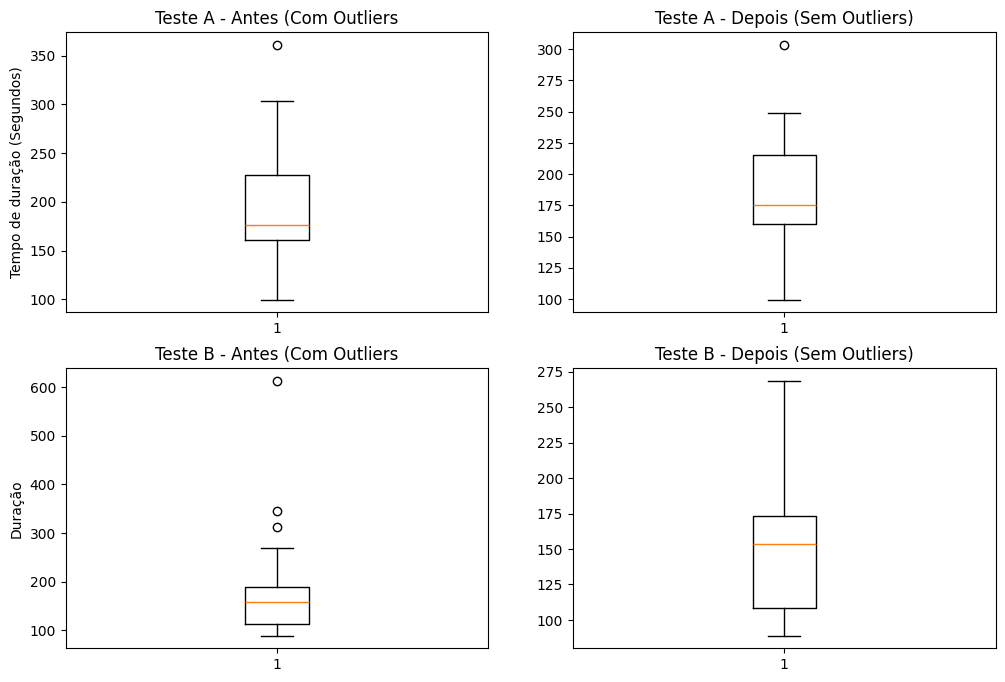

In [41]:

# Separar dados antes e depois por grupo
df_a = dfAB[dfAB['Teste'] == 'A']
df_b = dfAB[dfAB['Teste'] == 'B']

#Separando durações antes de remover os outliers
duracao_a_antes = df_a['Duracao']
duracao_a_depois = df_a['Duracao_Limite'].dropna()  # remove outliers (NaN que podem aparecer depois da remoção do outlier)

duracao_b_antes = df_b['Duracao']
duracao_b_depois = df_b['Duracao_Limite'].dropna()  # remove outliers

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Teste A - Antes
axs[0,0].boxplot(duracao_a_antes)
axs[0,0].set_title('Teste A - Antes (Com Outliers')
axs[0,0].set_ylabel('Tempo de duração (Segundos)')

# Teste A - Depois
axs[0,1].boxplot(duracao_a_depois)
axs[0,1].set_title('Teste A - Depois (Sem Outliers)')

# Teste B - Antes
axs[1,0].boxplot(duracao_b_antes)
axs[1,0].set_title('Teste B - Antes (Com Outliers')
axs[1,0].set_ylabel('Duração')

# Teste B - Depois
axs[1,1].boxplot(duracao_b_depois)
axs[1,1].set_title('Teste B - Depois (Sem Outliers)')

plt.show()




<h2>Calculo do T-test</h2>

In [43]:

result_iqr = pg.ttest(
    dfAB['Duracao_Limite'].loc[dfAB['Teste'] == 'B'].dropna(),
    dfAB['Duracao_Limite'].loc[dfAB['Teste'] == 'A'].dropna(),
    paired=False,
    alternative='less'
)

# Médias
mean_a_iqr = dfAB.loc[dfAB['Teste'] == 'A', 'Duracao_Limite'].mean()
mean_b_iqr = dfAB.loc[dfAB['Teste'] == 'B', 'Duracao_Limite'].mean()
ganhador = 'B' if mean_b_iqr < mean_a_iqr else 'A'

# T e p
t_valor = result_iqr['T']['T-test']
p_valor = result_iqr['p-val']['T-test']
graus_liberdade = math.floor(result_iqr['dof']['T-test'])
t_critico = stats.t.ppf(0.05, 30)  # conservador (grau de liberdade = 30)

print("Resultados Teste A/B")
print(f"Média A: {mean_a_iqr:.2f} | Média B: {mean_b_iqr:.2f}")
print(f"T-valor: {round(t_valor, 4)}")
# quantos desvios-padrão 
print(f"Grau de Liberdade: {graus_liberdade}")
print(f"T-crítico conservador (30): {round(t_critico, 3)}")
# limite de rejeição da hipótese nula 
print(f"P-valor: {round(p_valor, 4)}")
print(f"→ Grupo vencedor (menor tempo): {ganhador}")


Resultados Teste A/B
Média A: 185.06 | Média B: 149.84
T-valor: -2.1438
Grau de Liberdade: 33
T-crítico conservador (33): -1.692
P-valor: 0.0196
→ Grupo vencedor (menor tempo): B
